# Multi-label Image Classification with PASCAL VOC 2012

Authors: Matteo Picozzi and Marco Napolitano

> **Historical outputs:** retained plots and metrics come from the original course-project run, which indexed 17,125 XML annotations from a locally packaged dataset. The dataset loader and learning-rate callbacks below have since been corrected, and the comparison now uses predictions saved before fine-tuning. These changes have not been rerun with the full dataset. Historical outputs are illustrative, not verified results of the current code. Restart the kernel and run all cells to regenerate them. See README.md for dataset setup and limitations.


### Imports

In [ ]:
import os
import glob
import gc
import math
import random
import hashlib
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import seaborn as sns
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score,
    label_ranking_average_precision_score, label_ranking_loss, coverage_error
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision

from PIL import Image
import xml.etree.ElementTree as ET

import heapq

In [ ]:
HAS_GPU = bool(tf.config.list_physical_devices("GPU"))
policy = mixed_precision.Policy("mixed_float16" if HAS_GPU else "float32")
mixed_precision.set_global_policy(policy)
print(f"Precision policy: {policy.name}; GPU available: {HAS_GPU}")


### Caricamento del dataset

Configure the official VOC2012 archive or an existing extracted dataset. Google Drive is not required.


In [ ]:
# Paths are relative to the notebook working directory.
DATA_DIR = Path("data")
VOC_ROOT = Path(os.environ.get("VOC2012_DIR", str(DATA_DIR / "VOCdevkit" / "VOC2012")))
ARCHIVE_PATH = DATA_DIR / "VOCtrainval_11-May-2012.tar"
DOWNLOAD_DATASET = False  # Set True to download the approximately 2 GB archive.
DATASET_URL = "https://thor.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"
ARCHIVE_MD5 = "6cd6e144f989b92b3379bac3b3de84fd"


Download or extract the official archive. Extraction uses a safe TAR filter and checks the archive checksum. An already extracted dataset can be selected through `VOC_ROOT` or the `VOC2012_DIR` environment variable.


In [ ]:
import tarfile
import urllib.request


def prepare_voc2012(data_dir, voc_root, archive_path, download=False):
    data_dir, voc_root, archive_path = map(Path, (data_dir, voc_root, archive_path))

    def dataset_ready(path):
        return (
            (path / "Annotations").is_dir()
            and (path / "JPEGImages").is_dir()
            and (path / "ImageSets" / "Main" / "trainval.txt").is_file()
        )

    if dataset_ready(voc_root):
        return voc_root

    if not archive_path.is_file():
        if not download:
            raise FileNotFoundError(
                "VOC2012 data not found. Follow README.md: download the official "
                f"archive to {archive_path}, set DOWNLOAD_DATASET=True, or point "
                "VOC_ROOT to an extracted VOCdevkit/VOC2012 directory."
            )
        archive_path.parent.mkdir(parents=True, exist_ok=True)
        partial_path = archive_path.with_name(archive_path.name + ".part")
        print("Downloading VOC2012 (approximately 2 GB)...")
        try:
            urllib.request.urlretrieve(DATASET_URL, partial_path)
            partial_path.replace(archive_path)
        except Exception:
            partial_path.unlink(missing_ok=True)
            raise

    digest = hashlib.md5()
    with archive_path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    if digest.hexdigest() != ARCHIVE_MD5:
        raise ValueError(
            "VOC2012 archive checksum mismatch. Download the official archive "
            "again; renaming a ZIP file to .tar does not convert it."
        )

    data_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive_path, "r:*") as archive:
        archive.extractall(data_dir, filter="data")

    if not dataset_ready(voc_root):
        raise FileNotFoundError(
            f"Expected Annotations/, JPEGImages/ and ImageSets/Main/trainval.txt "
            f"under {voc_root}. Check VOC_ROOT and the extracted directory structure."
        )
    return voc_root


voc_root = prepare_voc2012(DATA_DIR, VOC_ROOT, ARCHIVE_PATH, DOWNLOAD_DATASET)
print(f"Dataset ready: {voc_root}")


The official test images exist, but their classification ground truth is not publicly released. This experiment uses `ImageSets/Main/trainval.txt` and creates its own seeded 70/15/15 training/validation/test split. The internal test results are not official VOC2012 benchmark scores.


In [ ]:
TRAINVAL_ROOT = str(voc_root)
print(f"Train/validation source: {TRAINVAL_ROOT}")


### EDA

Configurazione e indicizzazione delle classi VOC e split dei path in "Annotations" e "JPEGImages"

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor",
]
CLASS_TO_IDX = {c:i for i,c in enumerate(VOC_CLASSES)}
NUM_CLASSES = len(VOC_CLASSES)

def split_paths(root):
    ann_dir = os.path.join(root, "Annotations")
    img_dir = os.path.join(root, "JPEGImages")
    return ann_dir, img_dir

TR_ANN, TR_IMG = split_paths(TRAINVAL_ROOT)

print("Train/Val:", TRAINVAL_ROOT)
print("Train/Val Annotations exists:", os.path.isdir(TR_ANN), "| JPEGImages exists:", os.path.isdir(TR_IMG))



Train/Val: data_local/VOC2012_train_val/VOC2012_train_val
Train/Val Annotations exists: True | JPEGImages exists: True


Parser per file XML contenuti in "Annotations"

In [7]:
def parse_voc_xml(xml_path):

    root = ET.parse(xml_path).getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width"))
    height = int(size.findtext("height"))

    objects = []
    labels = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name not in CLASS_TO_IDX:
            continue

        difficult = int(obj.findtext("difficult", default="0"))
        truncated = int(obj.findtext("truncated", default="0"))

        bnd = obj.find("bndbox")
        xmin = int(float(bnd.findtext("xmin")))
        ymin = int(float(bnd.findtext("ymin")))
        xmax = int(float(bnd.findtext("xmax")))
        ymax = int(float(bnd.findtext("ymax")))

        bw = max(0, xmax - xmin)
        bh = max(0, ymax - ymin)

        objects.append({
            "class": name,
            "difficult": difficult,
            "truncated": truncated,
            "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
            "box_w": bw, "box_h": bh,
        })
        labels.append(name)

    labels = sorted(set(labels))
    return {
        "filename": filename,
        "width": width,
        "height": height,
        "labels": labels,
        "objects": objects,
        "n_objects": len(objects),
    }

Indicizza un split leggendo tutti gli XML e cercando il .jpg corrispondente

ID = nome file senza estensione (es: 2008_000002)

In [ ]:
def build_index_from_folder(root, split_name):
    ann_dir, img_dir = split_paths(root)
    image_set = Path(root) / "ImageSets" / "Main" / f"{split_name}.txt"
    if not image_set.is_file():
        raise FileNotFoundError(f"VOC image list not found: {image_set}")
    image_ids = sorted(set(image_set.read_text().split()))
    if not image_ids:
        raise ValueError(f"VOC image list is empty: {image_set}")
    xml_files = [os.path.join(ann_dir, f"{image_id}.xml") for image_id in image_ids]
    missing_xml = [path for path in xml_files if not os.path.isfile(path)]
    if missing_xml:
        raise FileNotFoundError(f"Missing {len(missing_xml)} XML annotations; first: {missing_xml[0]}")

    rows = []
    for xml_path in xml_files:
        img_id = os.path.splitext(os.path.basename(xml_path))[0]

        candidates = [
            os.path.join(img_dir, f"{img_id}.jpg")
        ]


        img_path = next((p for p in candidates if os.path.exists(p)), None)



        if img_path is None:
            rows.append({
                "split": split_name,
                "id": img_id,
                "xml_path": xml_path,
                "img_path": None,
                "missing_image": True,
            })
            continue

        try:
            d = parse_voc_xml(xml_path)
            rows.append({
                "split": split_name,
                "id": img_id,
                "xml_path": xml_path,
                "img_path": img_path,
                "missing_image": False,
                "width": d["width"],
                "height": d["height"],
                "aspect_ratio": d["width"] / max(1, d["height"]),
                "n_objects": d["n_objects"],
                "labels": d["labels"],
            })
        except Exception as e:
            rows.append({
                "split": split_name,
                "id": img_id,
                "xml_path": xml_path,
                "img_path": img_path,
                "missing_image": False,
                "parse_error": True,
                "error": str(e)[:200],
            })

    return pd.DataFrame(rows)

df = build_index_from_folder(TRAINVAL_ROOT, "trainval")

print("rows:", len(df))
print("Missing images:", int(df.get("missing_image", False).sum()))
print("Parse errors:", int(df["parse_error"].sum() if "parse_error" in df.columns else 0))
df.head()


Distribuzioni numero oggetti per immagine

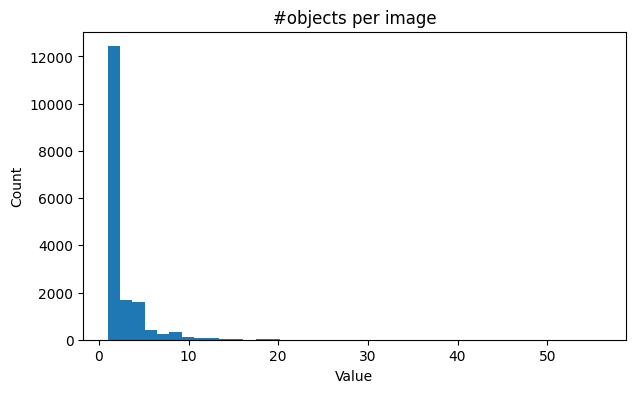

n_objects stats:
 count    17125.000000
mean         2.343825
std          2.421888
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         56.000000
Name: n_objects, dtype: float64


In [9]:
def plot_hist(series, title, bins=30):
    plt.figure(figsize=(7,4))
    plt.hist(series.dropna().values, bins=bins)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.show()

plot_hist(df["n_objects"], "#objects per image", bins=40)

print("n_objects stats:\n", df["n_objects"].describe())


Dimensioni immagini + aspect ratio

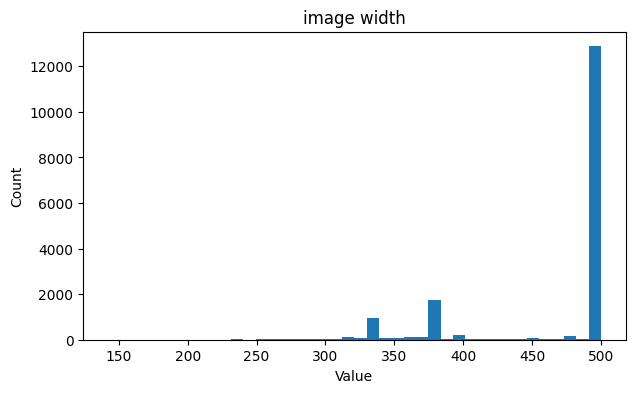

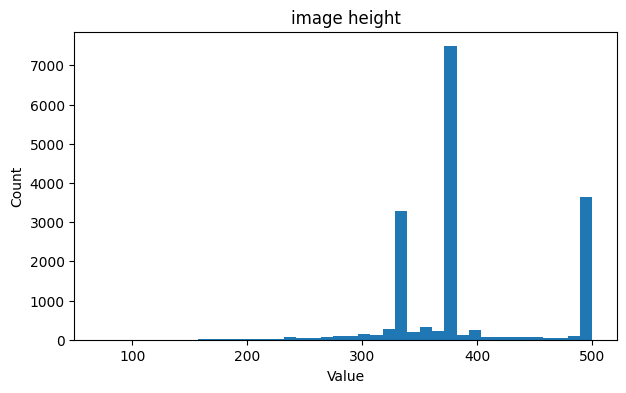

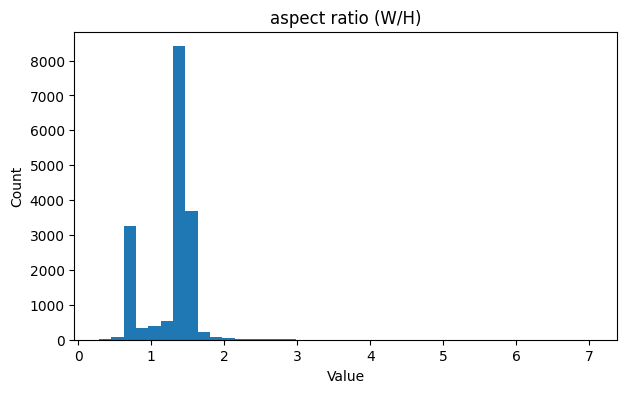

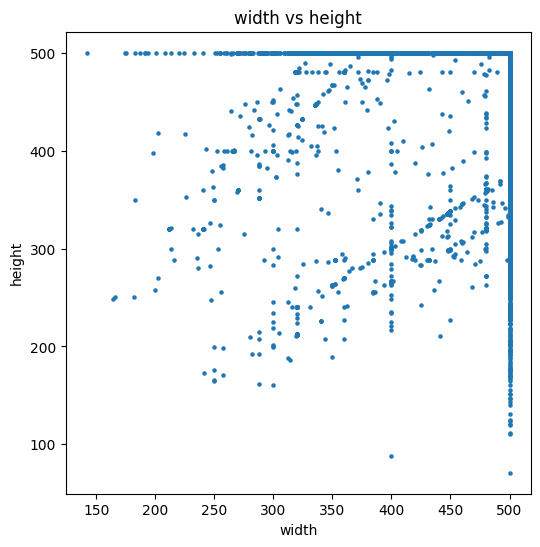

In [10]:
plot_hist(df["width"], "image width", bins=40)
plot_hist(df["height"], "image height", bins=40)
plot_hist(df["aspect_ratio"], "aspect ratio (W/H)", bins=40)

tmp = df[["width","height"]].dropna()
plt.figure(figsize=(6,6))
plt.scatter(tmp["width"], tmp["height"], s=5)
plt.title("width vs height")
plt.xlabel("width")
plt.ylabel("height")
plt.show()

Distribuzione classi

In [11]:
def multilabel_counts(df_split):
    c = Counter()
    for labels in df_split["labels"].dropna():
        for lab in labels:
            c[lab] += 1
    return pd.Series({k: c.get(k, 0) for k in VOC_CLASSES}).sort_values(ascending=False)

trainval_class_img_counts = multilabel_counts(df)

class_df = pd.DataFrame({
    "img_count": trainval_class_img_counts,
}).fillna(0).astype(int)

class_df.head(20)

,img_count
person,9583
chair,1366
dog,1341
car,1284
cat,1128
bottle,812
bird,811
sofa,742
aeroplane,716
diningtable,691


Barplot dello sbilanciamento tra classi

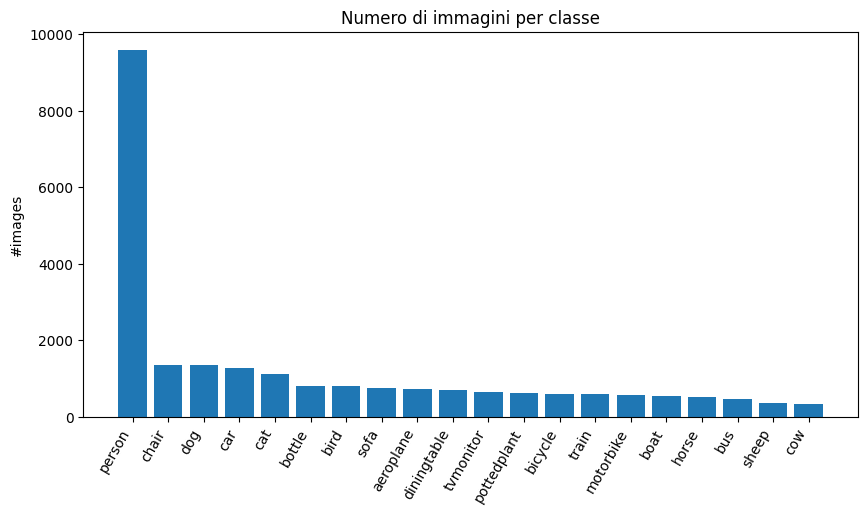

Imbalance ratio (max/min): 28.185294117647057


In [12]:
plt.figure(figsize=(10,5))
plt.bar(class_df.index, class_df["img_count"].values)
plt.title("Numero di immagini per classe")
plt.xticks(rotation=60, ha="right")
plt.ylabel("#images")
plt.show()

imbalance_ratio = class_df["img_count"].max() / max(1, class_df["img_count"].min())
print("Imbalance ratio (max/min):", float(imbalance_ratio))

Co-occorrenza tra classi

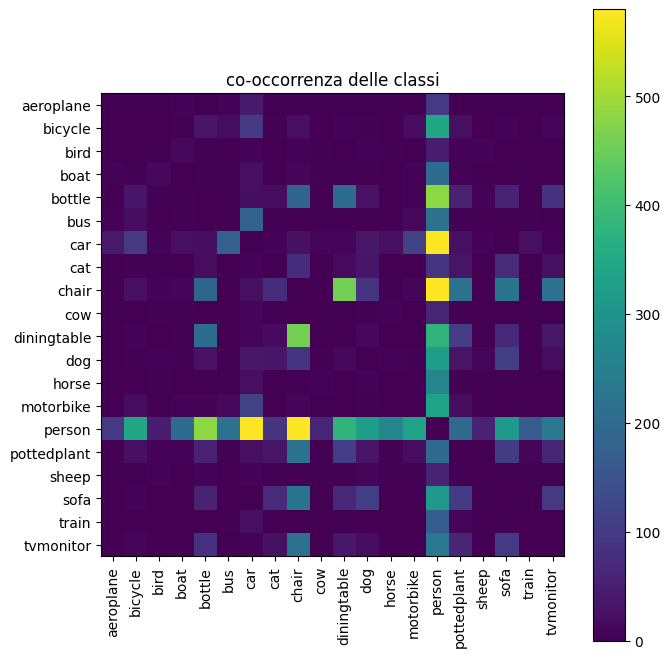

In [13]:
def cooccurrence_matrix(df_split):
    mat = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int32)
    for labels in df_split["labels"].dropna():
        idxs = [CLASS_TO_IDX[l] for l in labels]
        for i in idxs:
            for j in idxs:
                mat[i, j] += 1
    return mat

co_mat = cooccurrence_matrix(df)
np.fill_diagonal(co_mat, 0)

plt.figure(figsize=(7,7))
plt.imshow(co_mat)
plt.title("co-occorrenza delle classi")
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=90)
plt.yticks(range(NUM_CLASSES), VOC_CLASSES)
plt.colorbar()
plt.tight_layout()
plt.show()

Bounding box

ID=2010_001328 | labels=['cat'] | n_objects=1 | size=500x376


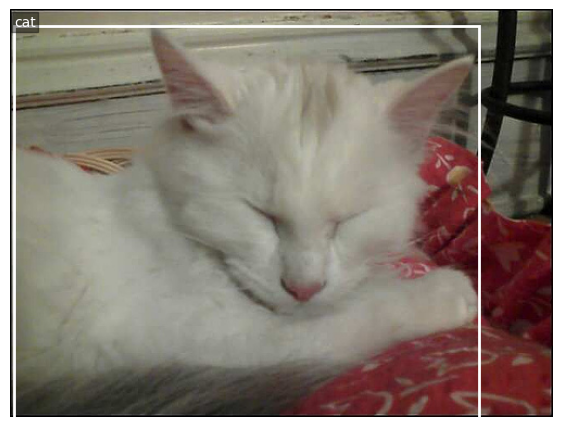

ID=2009_000343 | labels=['motorbike', 'person'] | n_objects=8 | size=500x375


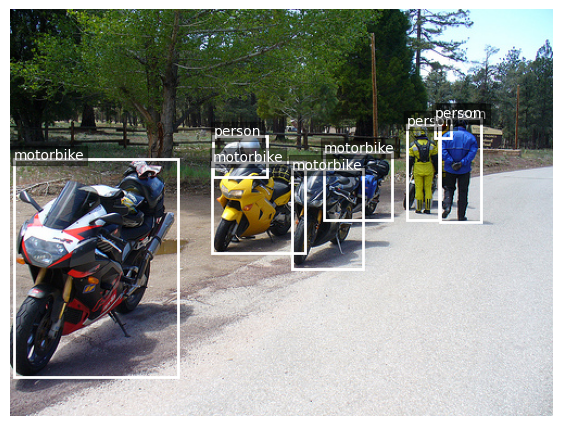

ID=2010_006252 | labels=['person'] | n_objects=1 | size=500x333


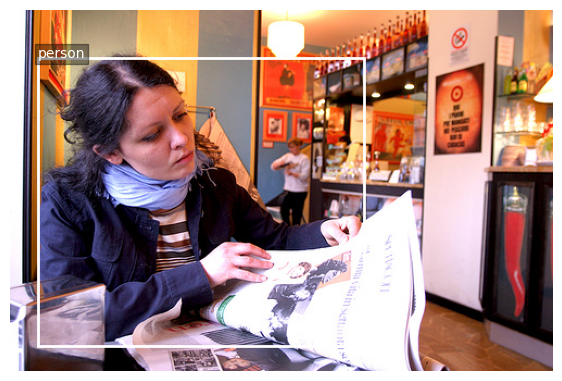

ID=2011_005635 | labels=['person'] | n_objects=1 | size=309x500


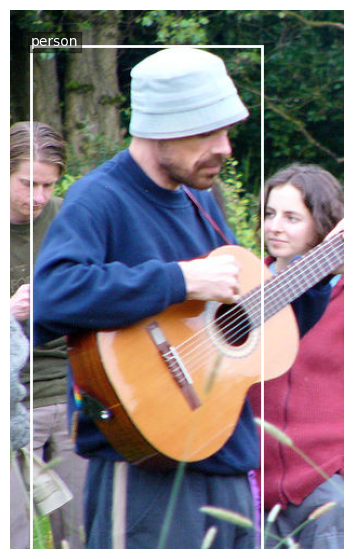

ID=2009_001521 | labels=['person'] | n_objects=3 | size=375x500


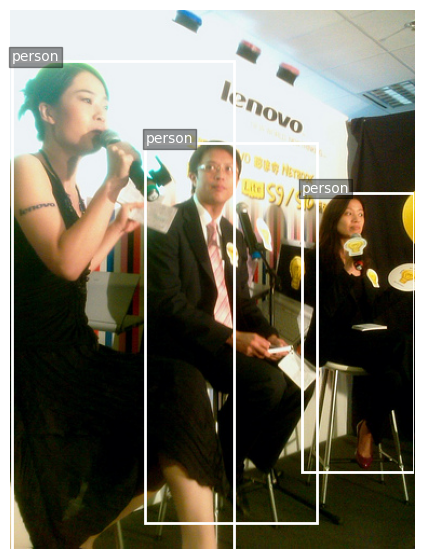

ID=2010_004119 | labels=['motorbike'] | n_objects=1 | size=500x333


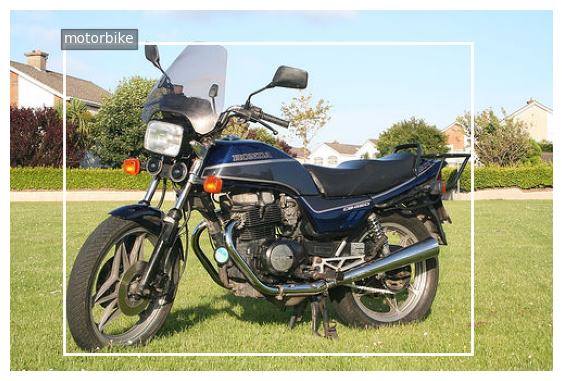

In [14]:
def draw_bboxes(img, objects, max_boxes=20):
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img)
    for obj in objects[:max_boxes]:
        x1,y1,x2,y2 = obj["xmin"], obj["ymin"], obj["xmax"], obj["ymax"]
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor="white", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1, obj["class"], color="white", fontsize=10,
                bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.axis("off")
    return fig

def show_random_samples(df_split, n=6):
    samples = df_split.sample(min(n, len(df_split)), random_state=random.randint(0, 10_000))
    for _, row in samples.iterrows():
        d = parse_voc_xml(row["xml_path"])
        img = Image.open(row["img_path"]).convert("RGB")
        print(f"ID={row['id']} | labels={d['labels']} | n_objects={d['n_objects']} | size={d['width']}x{d['height']}")
        draw_bboxes(img, d["objects"])
        plt.show()

show_random_samples(df, n=6)

Multihot enconding sulle etichette

In [15]:
def labels_to_multihot(labels):
    y = np.zeros((NUM_CLASSES,), dtype=np.float32)
    for lab in labels:
        y[CLASS_TO_IDX[lab]] = 1.0
    return y

Y_trainval = np.stack([labels_to_multihot(labs) for labs in df["labels"].dropna()])
print("shape:", Y_trainval.shape)
print("Avg #classes per image:", Y_trainval.sum(axis=1).mean())
print("Max #classes per image:", Y_trainval.sum(axis=1).max())

shape: (17125, 20)
Avg #classes per image: 1.3861606
Max #classes per image: 6.0


Riassunto delle informazioni ottenute dall'analisi esplorativa del dataset

In [16]:
def eda_summary(df_split, name):
    ok = df_split.dropna(subset=["labels","width","height","n_objects"])
    cls_counts = multilabel_counts(df_split)
    return {
        "split": name,
        "n_images": int(len(ok)),
        "avg_objects": float(ok["n_objects"].mean()),
        "median_objects": float(ok["n_objects"].median()),
        "avg_w": float(ok["width"].mean()),
        "avg_h": float(ok["height"].mean()),
        "aspect_median": float(ok["aspect_ratio"].median()),
        "avg_labels_per_img": float(np.mean([len(x) for x in ok["labels"]])),
        "min_class_img_count": int(cls_counts.min()),
        "max_class_img_count": int(cls_counts.max()),
    }

pd.DataFrame([eda_summary(df,"trainval")])

,split,n_images,avg_objects,median_objects,avg_w,avg_h,aspect_median,avg_labels_per_img,min_class_img_count,max_class_img_count
0,trainval,17125,2.343825,1.0,466.797547,389.50762,1.333333,1.386161,340,9583


## Configurazione dei dati

Suddivisione dei dati in train/val/test utilizzando il dataset di train, in quanto quello di test non e' disponibile. Lo split viene effettuato con proporzioni rispettivamente pari a 70%, 15%, 15%.

In [17]:
BATCH_SIZE = 64
IMG_SIZE = (224, 224)
SEED = 42
VAL_SIZE  = 0.15
TEST_SIZE = 0.15

df_clean = df.dropna(subset=["img_path", "labels"]).reset_index(drop=True)
dropped = len(df) - len(df_clean)
if dropped:
    print(f"Eliminazione righe con dati mancanti: {dropped}")

df_shuffled = df_clean.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_total = len(df_shuffled)
n_test  = int(n_total * TEST_SIZE)
n_val   = int(n_total * VAL_SIZE)

n_train = n_total - n_test - n_val

df_test  = df_shuffled.iloc[:n_test].reset_index(drop=True)
df_val   = df_shuffled.iloc[n_test : n_test + n_val].reset_index(drop=True)
df_train = df_shuffled.iloc[n_test + n_val:].reset_index(drop=True)

print("-" * 30)
print(f"DATI SUDDIVISI")
print(f"   Totale Immagini: {n_total}")
print(f"   TRAIN Set:       {len(df_train)} ({(len(df_train)/n_total):.1%})")
print(f"   VAL Set:         {len(df_val)}   ({(len(df_val)/n_total):.1%})")
print(f"   TEST Set:        {len(df_test)}  ({(len(df_test)/n_total):.1%})")
print("-" * 30)


------------------------------
DATI SUDDIVISI
   Totale Immagini: 17125
   TRAIN Set:       11989 (70.0%)
   VAL Set:         2568   (15.0%)
   TEST Set:        2568  (15.0%)
------------------------------


Costruzione di una pipeline per un problema multi-label e definizione di una Binary Cross Entropy pesata per gestire lo sbilanciamento tra classi.


In [18]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img

def make_ds(df_split, training=False):
    paths = df_split["img_path"].values
    y_matrix = np.stack([labels_to_multihot(labs) for labs in df_split["labels"]])

    ds = tf.data.Dataset.from_tensor_slices((paths, y_matrix))

    if training:
        ds = ds.shuffle(len(df_split), seed = SEED, reshuffle_each_iteration=True)

    def _loader(p, y):
        return load_image(p), tf.cast(y, tf.float32)

    ds = ds.map(_loader, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(df_train, training=True)
val_ds   = make_ds(df_val, training=False)
test_ds  = make_ds(df_test, training=False)

Y_train_np = np.stack([labels_to_multihot(labs) for labs in df_train["labels"]])
pos_counts = Y_train_np.sum(axis=0)
neg_counts = len(Y_train_np) - pos_counts
pos_weights = (neg_counts + 1e-6) / (pos_counts + 1e-6)
pos_weights = np.clip(pos_weights, 1.0, 15.0)
pos_weights_tf = tf.constant(pos_weights, dtype=tf.float32)

def weighted_bce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    loss_pos = -y_true * tf.math.log(y_pred) * pos_weights_tf
    loss_neg = -(1.0 - y_true) * tf.math.log(1.0 - y_pred)
    return tf.reduce_mean(loss_pos + loss_neg)

## Modello CNN

### CNN

CNN custom

In [19]:
def cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1./255)(inputs)

    data_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ])

    x = data_aug(x)

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid', dtype='float32')(x)

    return keras.Model(inputs, outputs, name="Baseline_CNN")

model_cnn = cnn(IMG_SIZE + (3,), NUM_CLASSES)
model_cnn.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 725,940 (2.77 MB)

 Trainable params: 724,980 (2.77 MB)

 Non-trainable params: 960 (3.75 KB)

Training del modello

In [20]:
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=weighted_bce_loss,
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc_pr", curve="PR", multi_label=True)
    ]
)

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=2, min_lr=1e-6)
    ]
)


Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 89s 288ms/step - auc_pr: 0.1000 - bin_acc: 0.7273 - loss: 1.0087 - val_auc_pr: 0.0765 - val_bin_acc: 0.6871 - val_loss: 1.5354 - learning_rate: 0.0010
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 101s 226ms/step - auc_pr: 0.1397 - bin_acc: 0.7729 - loss: 0.8987 - val_auc_pr: 0.1451 - val_bin_acc: 0.7415 - val_loss: 1.0925 - learning_rate: 0.0010
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - auc_pr: 0.1617 - bin_acc: 0.7833 - loss: 0.8445 - val_auc_pr: 0.1953 - val_bin_acc: 0.7728 - val_loss: 0.8355 - learning_rate: 0.0010
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 80s 214ms/step - auc_pr: 0.1827 - bin_acc: 0.7954 - loss: 0.7996 - val_auc_pr: 0.2101 - val_bin_acc: 0.8004 - val_loss: 0.8348 - learning_rate: 5.0000e-04
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 206ms/step - auc_pr: 0.1909 - bin_acc: 0.7976 - loss: 0.7871 - val_auc_pr: 0.2093 - val_bin_acc: 0.7748 - val_loss: 0.8523 - learning_rate: 5.0000e-04
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━

### Valutazione del modello

In [21]:
def labels_from_dataset(dataset):
    return np.concatenate([y.numpy() for _, y in dataset], axis=0)

def predict_dataset(model, dataset, label):
    print(f"Predizioni su {label}...")
    y_probs = model.predict(dataset, verbose=1)
    y_true = labels_from_dataset(dataset)
    return y_true, y_probs

def safe_average_precision(y_true, y_probs):
    return average_precision_score(y_true, y_probs) if (y_true.max() != y_true.min()) else np.nan


def plot_training_curves(history, title):
    h = history.history

    def _plot_metric(metric_name, ylabel):
        if metric_name not in h:
            return
        plt.figure(figsize=(6, 4))
        plt.plot(h[metric_name], label=f"train_{metric_name}")
        val_key = f"val_{metric_name}"
        if val_key in h:
            plt.plot(h[val_key], label=val_key)
        plt.title(f"{title} - {metric_name}")
        plt.xlabel("epoch")
        plt.ylabel(ylabel)

        if metric_name in ['auc_pr', 'bin_acc', 'accuracy', 'precision', 'recall']:
            plt.ylim(-0.05, 1.05)
        elif metric_name == 'loss':
            plt.ylim(bottom=0)

        plt.legend()
        plt.tight_layout()
        plt.show()

    _plot_metric("loss", "loss")
    _plot_metric("auc_pr", "AUC (PR)")
    _plot_metric("bin_acc", "binary accuracy")

def compute_optimal_thresholds(y_true, y_probs, class_names):
    thresholds = np.full(len(class_names), 0.5, dtype=np.float32)
    rows = []

    for i, class_name in enumerate(class_names):
        y_t = y_true[:, i]
        y_p = y_probs[:, i]

        ap_val = safe_average_precision(y_t, y_p)
        precisions, recalls, thresholds_arr = precision_recall_curve(y_t, y_p)

        if len(thresholds_arr) > 0:
            f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
            best_idx = int(np.argmax(f1_scores))
            best_thresh = float(thresholds_arr[best_idx])
            best_f1 = float(f1_scores[best_idx])
        else:
            best_thresh = 0.5
            best_f1 = np.nan

        thresholds[i] = best_thresh

        rows.append({
            "Class": class_name,
            "AP_val": ap_val,
            "BestF1_val": best_f1,
            "BestThresh_val": best_thresh,
            "Support_val": int(y_t.sum())
        })

    df_val_metrics = pd.DataFrame(rows).sort_values("AP_val", ascending=False)
    mAP_val = np.nanmean(df_val_metrics["AP_val"].values)
    return thresholds, df_val_metrics, mAP_val

def evaluate_with_thresholds(y_true, y_probs, thresholds, class_names):
    y_pred = (y_probs >= thresholds[None, :]).astype(np.int32)

    summary = {
        "micro_p": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_r": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_f": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_p": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_r": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "samples_f": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "micro_ap": average_precision_score(y_true, y_probs, average="micro"),
        "macro_ap": average_precision_score(y_true, y_probs, average="macro"),
    }

    rows = []
    for i, class_name in enumerate(class_names):
        y_t = y_true[:, i]
        y_p = y_probs[:, i]
        y_b = y_pred[:, i]

        ap_test = safe_average_precision(y_t, y_p)
        p = precision_score(y_t, y_b, zero_division=0)
        r = recall_score(y_t, y_b, zero_division=0)
        f = f1_score(y_t, y_b, zero_division=0)

        rows.append({
            "Class": class_name,
            "AP_test": ap_test,
            "P_test": p,
            "R_test": r,
            "F1_test": f,
            "Thresh_used": float(thresholds[i]),
            "Support_test": int(y_t.sum())
        })

    df_test_metrics = pd.DataFrame(rows).sort_values("AP_test", ascending=False)
    mAP_test = np.nanmean(df_test_metrics["AP_test"].values)
    return y_pred, df_test_metrics, mAP_test, summary

def print_val_report(df_val_metrics, mAP_val):
    print(f"VAL mAP: {mAP_val:.4f}")
    print("Top 5 classi (VAL):")
    print(df_val_metrics.head(5).to_string(index=False))
    print("\nWorst 5 classi (VAL):")
    print(df_val_metrics.tail(5).to_string(index=False))

def print_test_report(summary, mAP_test):
    print("\n==================== REPORT TEST (soglie da VAL) ====================")
    print(f"AP micro (TEST):   {summary['micro_ap']:.4f}")
    print(f"AP macro (TEST):   {summary['macro_ap']:.4f}")
    print(f"F1 micro (TEST):   {summary['micro_f']:.4f}  | P: {summary['micro_p']:.4f}  R: {summary['micro_r']:.4f}")
    print(f"F1 macro (TEST):   {summary['macro_f']:.4f}  | P: {summary['macro_p']:.4f}  R: {summary['macro_r']:.4f}")
    print(f"F1 samples (TEST): {summary['samples_f']:.4f}")
    print(f"TEST mAP (per-classe): {mAP_test:.4f}")
    print("=====================================================================")

def plot_class_ap(df_test_metrics, mAP_test):
    sns.set_style("whitegrid")
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_test_metrics, x="Class", y="AP_test", hue="Class", legend=False)
    plt.title(f"Average Precision per Classe (TEST) -- mAP={mAP_test:.2f}")
    plt.xticks(rotation=90)
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=df_test_metrics,
        x="Thresh_used", y="Class",
        size="Support_test", sizes=(20, 400),
        hue="AP_test"
    )
    plt.title("Soglia (da VAL) vs Classe -- Colore=AP_test, Dimensione=Support_test")
    plt.xlabel("Soglia usata (calcolata su VAL)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_error_correlation(y_true, y_probs, class_names):
    residuals = y_probs - y_true
    corr_matrix = np.corrcoef(residuals.T)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, xticklabels=class_names, yticklabels=class_names,
                cmap="coolwarm", center=0, annot=False)
    plt.title("Correlazione degli errori tra classi (TEST)")
    plt.tight_layout()
    plt.show()

def print_thresholds(thresholds, class_names):
    thresholds_dict = {class_names[i]: float(thresholds[i]) for i in range(len(class_names))}
    print("=== Optimal thresholds (da VAL) per classe ===")
    for k, v in thresholds_dict.items():
        print(f"{k:12s} -> {v:.6f}")

def find_global_threshold(y_true, y_probs):
    grid = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_true, (y_probs >= t).astype(int), average="micro", zero_division=0) for t in grid]
    best_idx = int(np.argmax(scores))
    return float(grid[best_idx]), float(scores[best_idx])

def topk_metrics(y_true, y_probs, k=3):
    y_true = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    topk = np.argsort(y_probs, axis=1)[:, ::-1][:, :k]

    prec = []
    rec = []
    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if true_idx.size == 0:
            continue
        pred_idx = topk[i]
        hits = np.intersect1d(true_idx, pred_idx).size
        prec.append(hits / k)
        rec.append(hits / true_idx.size)

    return {
        f"P@{k}": float(np.mean(prec)) if prec else np.nan,
        f"R@{k}": float(np.mean(rec)) if rec else np.nan,
    }


def ranking_metrics(y_true, y_probs):
    return {
        "LRAP": float(label_ranking_average_precision_score(y_true, y_probs)),
        "RankingLoss": float(label_ranking_loss(y_true, y_probs)),
        "CoverageError": float(coverage_error(y_true, y_probs)),
    }


def results_row_extended(summary, mAP, y_true, y_probs, label, k=3):
    row = results_row(summary, mAP, label)
    row.update(ranking_metrics(y_true, y_probs))
    row.update(topk_metrics(y_true, y_probs, k=k))
    return row

def plot_pr_curves(y_true, y_probs, class_names, top_k=6, color="blue"):
    y_true = np.asarray(y_true)
    y_probs = np.asarray(y_probs)

    p_micro, r_micro, _ = precision_recall_curve(y_true.ravel(), y_probs.ravel())
    plt.figure(figsize=(6, 5))
    plt.plot(r_micro, p_micro, label="micro", color=color)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Micro-averaged PR curve")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    ap_scores = []
    for idx, name in enumerate(class_names):
        ap = safe_average_precision(y_true[:, idx], y_probs[:, idx])
        if not np.isnan(ap):
            ap_scores.append((ap, idx, name))
    ap_scores.sort(reverse=True)
    top = ap_scores[:top_k]

    plt.figure(figsize=(8, 6))
    for ap, idx, name in top:
        p, r, _ = precision_recall_curve(y_true[:, idx], y_probs[:, idx])
        plt.plot(r, p, label=f"{name} (AP={ap:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Top-{len(top)} class PR curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def results_row(summary, mAP, label):
    return {
        "Model": label,
        "mAP": float(mAP),
        "AP_micro": float(summary["micro_ap"]),
        "AP_macro": float(summary["macro_ap"]),
        "F1_micro": float(summary["micro_f"]),
        "F1_macro": float(summary["macro_f"]),
        "F1_samples": float(summary["samples_f"]),
    }


Viene creata una funzione wrapper che esegue l'intera valutazione: predizioni su val/test, scelta delle soglie ottimali, report e grafici. Include anche un helper per stampare metriche di ranking.

In [22]:
def run_evaluation(model, name, val_ds, test_ds, class_names):
    y_val_true, y_val_probs = predict_dataset(model, val_ds, f"VAL ({name})")
    y_test_true, y_test_probs = predict_dataset(model, test_ds, f"TEST ({name})")

    thresholds, df_val_metrics, mAP_val = compute_optimal_thresholds(
        y_val_true, y_val_probs, class_names
    )
    print_val_report(df_val_metrics, mAP_val)

    y_test_pred, df_test_metrics, mAP_test, summary = evaluate_with_thresholds(
        y_test_true, y_test_probs, thresholds, class_names
    )
    print_test_report(summary, mAP_test)

    plot_class_ap(df_test_metrics, mAP_test)
    plot_error_correlation(y_test_true, y_test_probs, class_names)
    print_thresholds(thresholds, class_names)

    t_global, f1_global = find_global_threshold(y_val_true, y_val_probs)
    print("=== Optimal GLOBAL threshold (micro-F1 su VAL) ===")
    print("t_global =", t_global, "| micro-F1 =", f1_global)

    return {
        "y_val_true": y_val_true,
        "y_val_probs": y_val_probs,
        "y_test_true": y_test_true,
        "y_test_probs": y_test_probs,
        "thresholds": thresholds,
        "df_val_metrics": df_val_metrics,
        "df_test_metrics": df_test_metrics,
        "mAP_val": mAP_val,
        "mAP_test": mAP_test,
        "summary": summary,
        "t_global": t_global,
        "f1_global": f1_global,
        "y_test_pred": y_test_pred,
    }


def print_ranking_summary(y_true, y_probs, label, k=3):
    rank = ranking_metrics(y_true, y_probs)
    topk = topk_metrics(y_true, y_probs, k=k)
    print(f"=== Ranking metrics ({label}) ===")
    print({**rank, **topk})


Esecuzione della valutazione del modello CNN baseline e salvataggio di tutte le variabili utili per le analisi successive.


In [23]:
def _to_uint8(img):
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

def _labels_from_vec(y_bin, class_names):
    idxs = np.where(y_bin == 1)[0]
    return [class_names[i] for i in idxs]

def _pred_labels_with_scores(probs, thresholds, class_names, topk=6):
    active = [(class_names[i], probs[i]) for i in range(len(class_names)) if probs[i] >= thresholds[i]]
    active.sort(key=lambda x: x[1], reverse=True)

    if len(active) == 0:
        top = np.argsort(probs)[::-1][:topk]
        return [f"{class_names[i]} {probs[i]:.0%}" for i in top], False
    else:
        return [f"{n} {s:.0%}" for n, s in active[:topk]], True

def show_best_worst_predictions(
    dataset,
    y_true,
    y_probs,
    thresholds_vec,
    class_names,
    k=6,
    max_items=None
):

    eps = 1e-7
    N = y_true.shape[0]
    C = y_true.shape[1]
    assert y_probs.shape == y_true.shape
    assert len(thresholds_vec) == C
    worst_heap = []
    best_heap = []

    global_idx = 0
    for batch_x, batch_y in dataset:
        bx = batch_x.numpy()
        bs = bx.shape[0]

        for j in range(bs):
            if max_items is not None and global_idx >= max_items:
                break

            yt = y_true[global_idx]
            yp = y_probs[global_idx]


            p = np.clip(yp, eps, 1.0 - eps)
            loss = -np.sum(yt * np.log(p) + (1 - yt) * np.log(1 - p))

            img_u8 = _to_uint8(bx[j])

            heapq.heappush(worst_heap, (loss, global_idx, img_u8, yt, yp))
            if len(worst_heap) > k:
                heapq.heappop(worst_heap)

            heapq.heappush(best_heap, (-loss, global_idx, img_u8, yt, yp))
            if len(best_heap) > k:
                heapq.heappop(best_heap)

            global_idx += 1

        if max_items is not None and global_idx >= max_items:
            break

    worst = sorted(worst_heap, key=lambda x: x[0], reverse=True)
    best  = sorted(best_heap, key=lambda x: x[0])
    best  = [(-neg_loss, idx, img, yt, yp) for (neg_loss, idx, img, yt, yp) in best]
    best  = sorted(best, key=lambda x: x[0])

    def _plot_grid(items, title):
        plt.figure(figsize=(18, 10))
        for i, (loss, idx, img, yt, yp) in enumerate(items):
            yb = (yp >= thresholds_vec).astype(int)

            tp = int(np.sum((yt == 1) & (yb == 1)))
            fp = int(np.sum((yt == 0) & (yb == 1)))
            fn = int(np.sum((yt == 1) & (yb == 0)))

            true_labs = _labels_from_vec(yt, class_names)
            pred_labs, used_thresholds = _pred_labels_with_scores(yp, thresholds_vec, class_names, topk=6)

            plt.subplot(2, 3, i + 1)
            plt.imshow(img)
            plt.axis("off")

            plt.title(
                f"idx={idx} | loss={loss:.2f} | TP={tp} FP={fp} FN={fn}\n"
                f"REAL: {true_labs}\n"
                f"PRED: {pred_labs}",
                fontsize=9,
                color=("red" if "Worst" in title else "green")
            )

        plt.suptitle(title, fontsize=14)
        plt.tight_layout()
        plt.show()

    _plot_grid(worst, f"Worst {k} predictions (highest loss)")
    _plot_grid(best,  f"Best {k} predictions (lowest loss)")

    return worst, best

Utility per ispezionare le migliori e peggiori predizioni: calcola la loss per sample e visualizza immagini con etichette reali e predette.

Predizioni su VAL (CNN baseline)...
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step
Predizioni su TEST (CNN baseline)...
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step
VAL mAP: 0.2893
Top 5 classi (VAL):
    Class   AP_val  BestF1_val  BestThresh_val  Support_val
   person 0.830515    0.771648        0.428052         1444
aeroplane 0.527009    0.560554        0.792538          118
      cat 0.392367    0.465632        0.646316          172
     boat 0.368567    0.369231        0.890424           80
      car 0.344042    0.425358        0.786735          195

Worst 5 classi (VAL):
      Class   AP_val  BestF1_val  BestThresh_val  Support_val
        cow 0.160622    0.240964        0.683119           45
      horse 0.145068    0.241071        0.503282           80
pottedplant 0.132094    0.243478        0.755545           87
     bottle 0.124077    0.208417        0.657932          141
    bicycle 0.107491    0.184818        0.667649           98

==================== REPORT TEST (soglie da VAL) ====

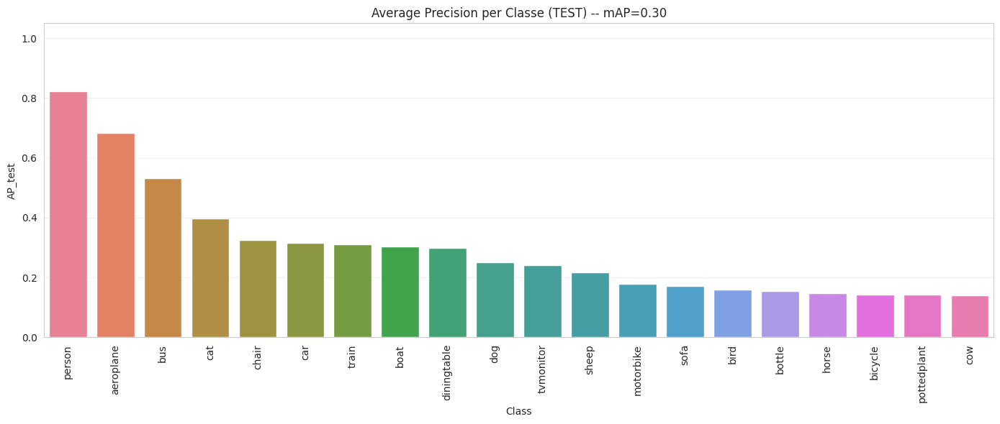

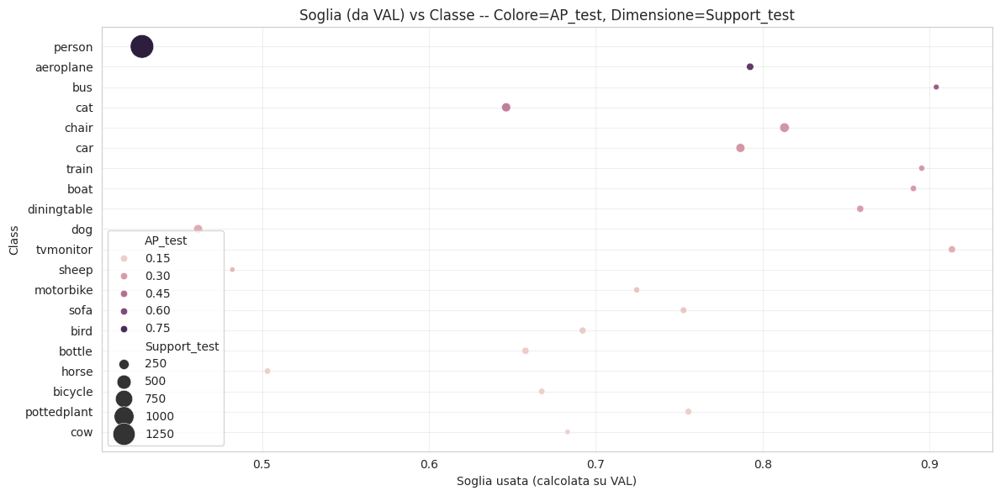

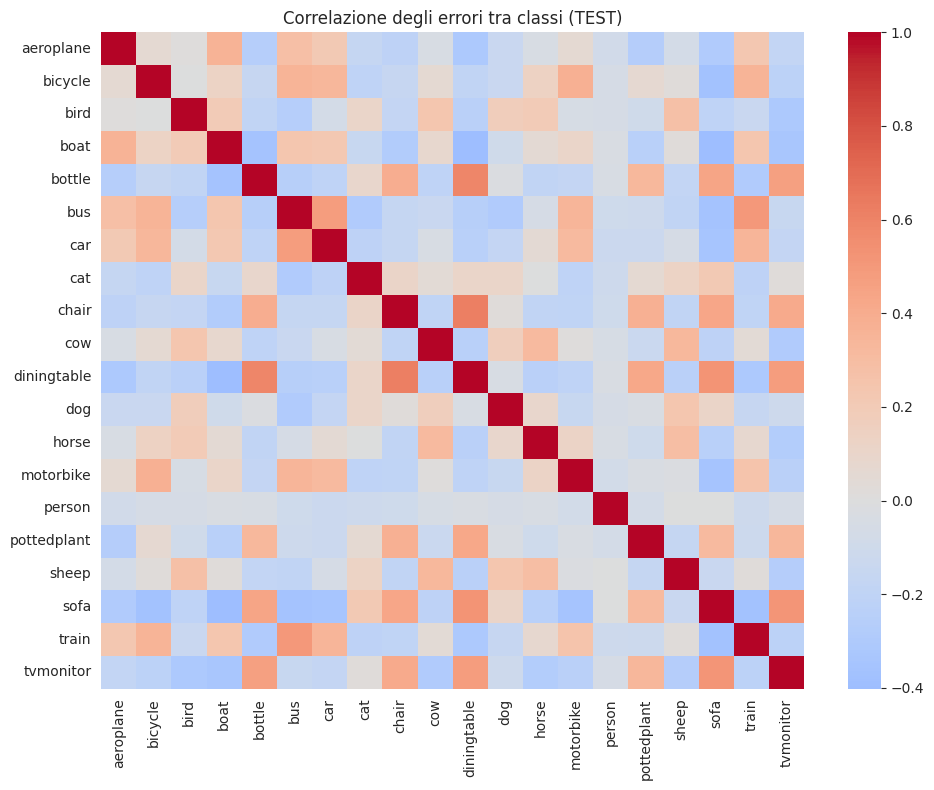

=== Optimal thresholds (da VAL) per classe ===
aeroplane    -> 0.792538
bicycle      -> 0.667649
bird         -> 0.692173
boat         -> 0.890424
bottle       -> 0.657932
bus          -> 0.904104
car          -> 0.786735
cat          -> 0.646316
chair        -> 0.813145
cow          -> 0.683119
diningtable  -> 0.858535
dog          -> 0.461692
horse        -> 0.503282
motorbike    -> 0.724569
person       -> 0.428052
pottedplant  -> 0.755545
sheep        -> 0.482205
sofa         -> 0.752614
train        -> 0.895372
tvmonitor    -> 0.913489
=== Optimal GLOBAL threshold (micro-F1 su VAL) ===
t_global = 0.6499999999999999 | micro-F1 = 0.3464186046511628
=== Ranking metrics (CNN baseline) ===
{'LRAP': 0.5261897457289791, 'RankingLoss': 0.15490411403227464, 'CoverageError': 4.725467289719626, 'P@3': 0.24597611630321908, 'R@3': 0.5520573727933541}


In [24]:
cnn_eval = run_evaluation(model_cnn, "CNN baseline", val_ds, test_ds, VOC_CLASSES)

thresholds_cnn = cnn_eval["thresholds"]
df_val_metrics_cnn = cnn_eval["df_val_metrics"]
df_test_metrics_cnn = cnn_eval["df_test_metrics"]
mAP_val_cnn = cnn_eval["mAP_val"]
mAP_test_cnn = cnn_eval["mAP_test"]
summary_cnn = cnn_eval["summary"]
y_val_true_cnn = cnn_eval["y_val_true"]
y_val_probs_cnn = cnn_eval["y_val_probs"]
y_test_true_cnn = cnn_eval["y_test_true"]
y_test_probs_cnn = cnn_eval["y_test_probs"]

t_global_cnn = cnn_eval["t_global"]
f1_global_cnn = cnn_eval["f1_global"]

print_ranking_summary(y_test_true_cnn, y_test_probs_cnn, "CNN baseline", k=3)

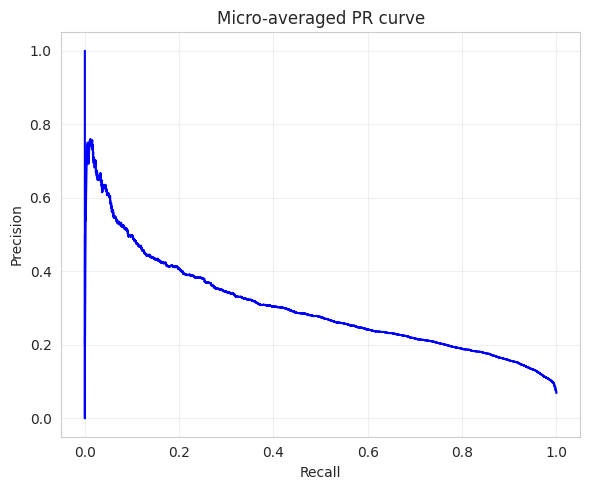

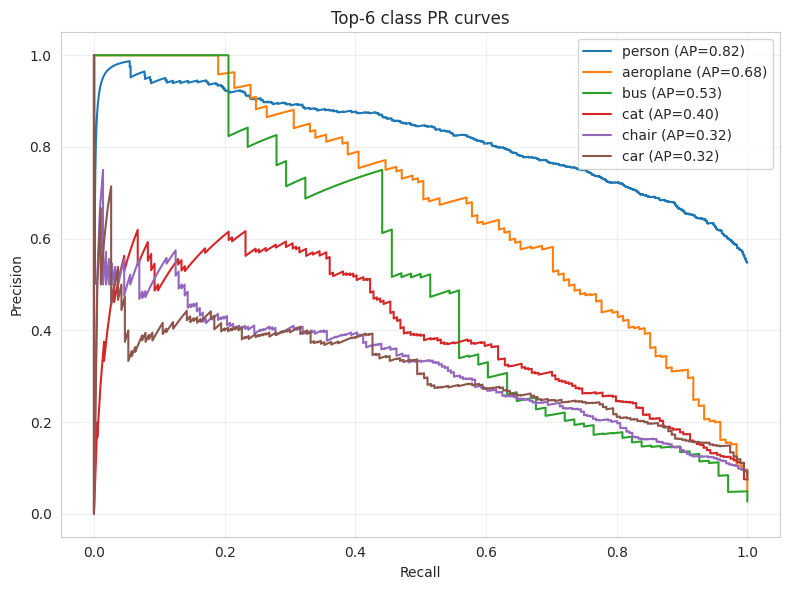

In [25]:
plot_pr_curves(y_test_true_cnn, y_test_probs_cnn, VOC_CLASSES, top_k=6)

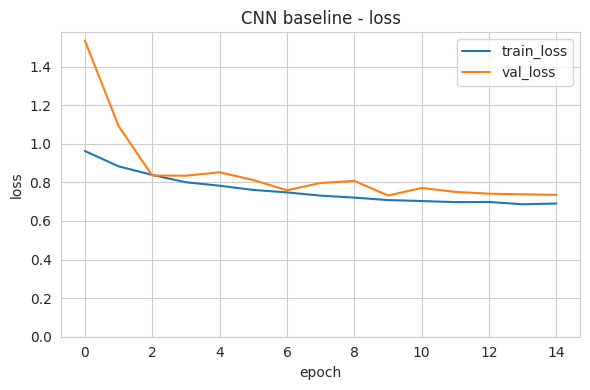

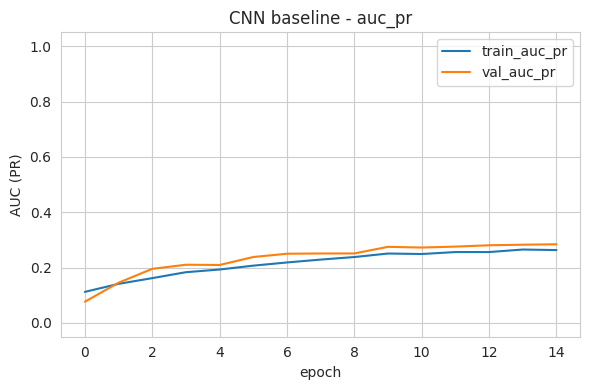

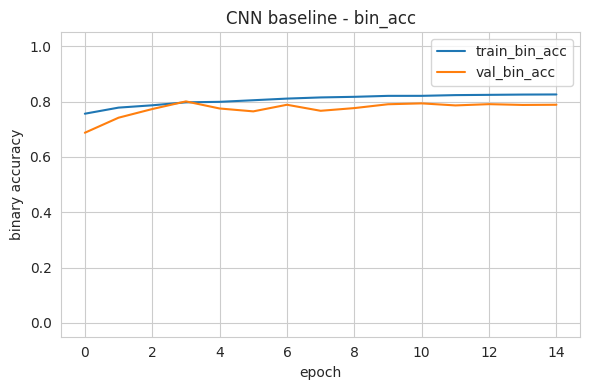

In [26]:
plot_training_curves(history_cnn, "CNN baseline")

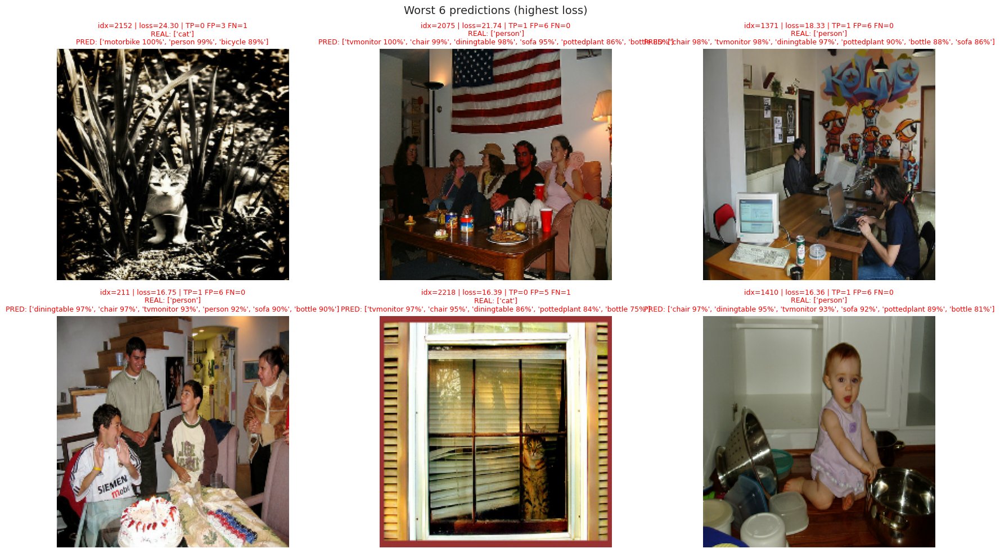

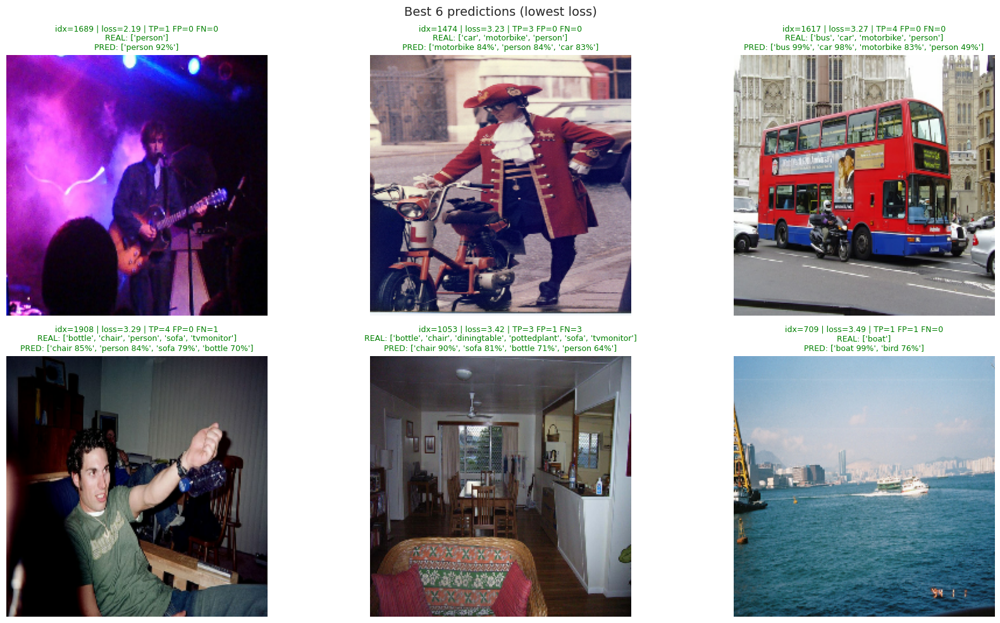

In [27]:
thresholds_vec = thresholds_cnn

worst, bestk = show_best_worst_predictions(
    dataset=test_ds,
    y_true=y_test_true_cnn,
    y_probs=y_test_probs_cnn,
    thresholds_vec=thresholds_vec,
    class_names=VOC_CLASSES,
    k=6
)

## Modello EfficientNet

### Definizione del modello

In [28]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid", dtype='float32')(x)

model = keras.Model(inputs, outputs, name="EfficientNet")

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=weighted_bce_loss,
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc_pr", curve="PR", multi_label=True)
    ]
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,075,191 (15.55 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Training del modello

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True)
    ]
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 153s 553ms/step - auc_pr: 0.3816 - bin_acc: 0.8199 - loss: 0.7503 - val_auc_pr: 0.7076 - val_bin_acc: 0.8953 - val_loss: 0.4636
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - auc_pr: 0.6697 - bin_acc: 0.9116 - loss: 0.4352 - val_auc_pr: 0.7314 - val_bin_acc: 0.9067 - val_loss: 0.4152
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 219ms/step - auc_pr: 0.6964 - bin_acc: 0.9211 - loss: 0.3848 - val_auc_pr: 0.7447 - val_bin_acc: 0.9134 - val_loss: 0.3931
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - auc_pr: 0.7147 - bin_acc: 0.9256 - loss: 0.3632 - val_auc_pr: 0.7488 - val_bin_acc: 0.9210 - val_loss: 0.3809
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - auc_pr: 0.7272 - bin_acc: 0.9277 - loss: 0.3520 - val_auc_pr: 0.7512 - val_bin_acc: 0.9167 - val_loss: 0.3760
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 38s 200ms/step - auc_pr: 0.7344 - bin_acc: 0.9283 - loss: 0.3371 - val_auc_pr: 0.7524 - val_bin_acc: 0.9194 - val_loss: 0.37

### Valutazione del modello

Predizioni su VAL (EfficientNet)...
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 228ms/step
Predizioni su TEST (EfficientNet)...
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step
VAL mAP: 0.7682
Top 5 classi (VAL):
    Class   AP_val  BestF1_val  BestThresh_val  Support_val
   person 0.974898    0.917884        0.373434         1444
    train 0.961056    0.917808        0.957428           75
      cat 0.957659    0.906344        0.978137          172
aeroplane 0.953729    0.937500        0.967028          118
    sheep 0.916420    0.885496        0.964826           71

Worst 5 classi (VAL):
      Class   AP_val  BestF1_val  BestThresh_val  Support_val
      horse 0.605756    0.650485        0.935302           80
       sofa 0.599400    0.593607        0.885041          116
      chair 0.583877    0.553299        0.848319          203
pottedplant 0.539476    0.565789        0.895074           87
     bottle 0.471741    0.489451        0.892344          141

==================== REPORT TEST (soglie da VAL) ===

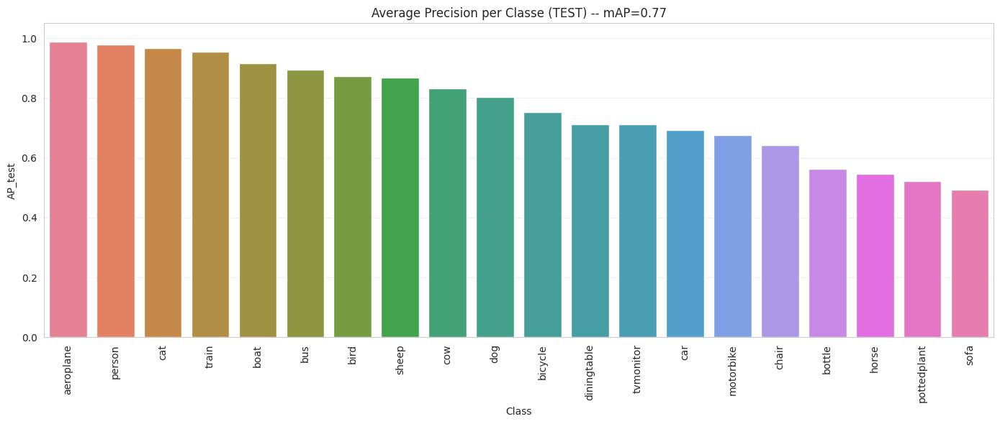

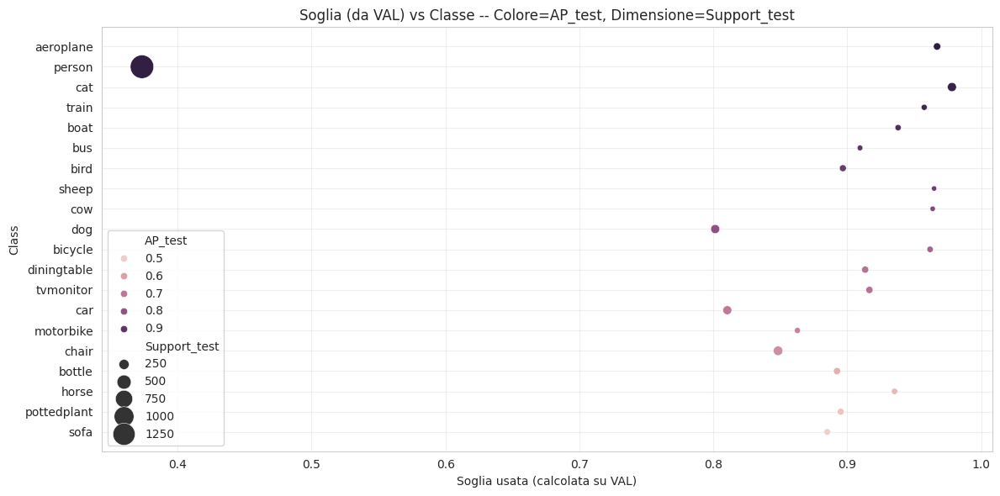

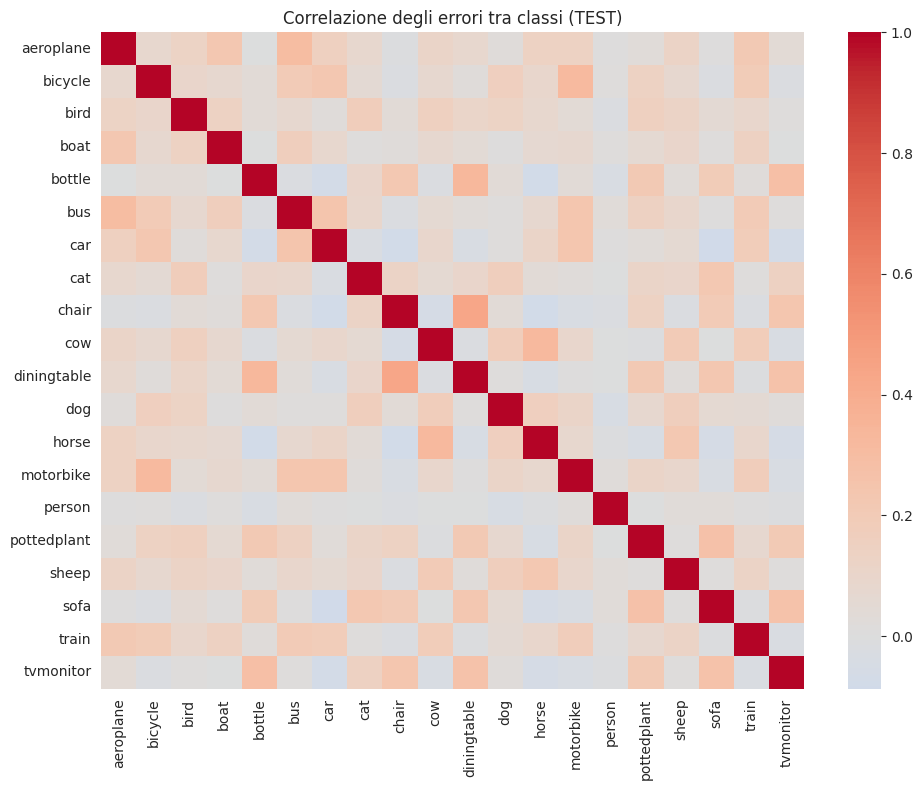

=== Optimal thresholds (da VAL) per classe ===
aeroplane    -> 0.967028
bicycle      -> 0.961823
bird         -> 0.896712
boat         -> 0.937933
bottle       -> 0.892344
bus          -> 0.909513
car          -> 0.810452
cat          -> 0.978137
chair        -> 0.848319
cow          -> 0.963765
diningtable  -> 0.913367
dog          -> 0.801405
horse        -> 0.935302
motorbike    -> 0.862796
person       -> 0.373434
pottedplant  -> 0.895074
sheep        -> 0.964826
sofa         -> 0.885041
train        -> 0.957428
tvmonitor    -> 0.916516
=== Optimal GLOBAL threshold (micro-F1 su VAL) ===
t_global = 0.83 | micro-F1 = 0.7429205996668518
=== Ranking metrics (EfficientNet) ===
{'LRAP': 0.8967686172712077, 'RankingLoss': 0.026532798004360515, 'CoverageError': 2.1366822429906542, 'P@3': 0.4092679127725857, 'R@3': 0.9259605399792317}


In [30]:
eff_eval = run_evaluation(model, "EfficientNet", val_ds, test_ds, VOC_CLASSES)

thresholds_eff = eff_eval["thresholds"]
df_val_metrics_eff = eff_eval["df_val_metrics"]
df_test_metrics_eff = eff_eval["df_test_metrics"]
mAP_val_eff = eff_eval["mAP_val"]
mAP_test_eff = eff_eval["mAP_test"]
summary_eff = eff_eval["summary"]
y_val_true_eff = eff_eval["y_val_true"]
y_val_probs_eff = eff_eval["y_val_probs"]
y_test_true_eff = eff_eval["y_test_true"]
y_test_probs_eff = eff_eval["y_test_probs"]

t_global_eff = eff_eval["t_global"]
f1_global_eff = eff_eval["f1_global"]

print_ranking_summary(y_test_true_eff, y_test_probs_eff, "EfficientNet", k=3)


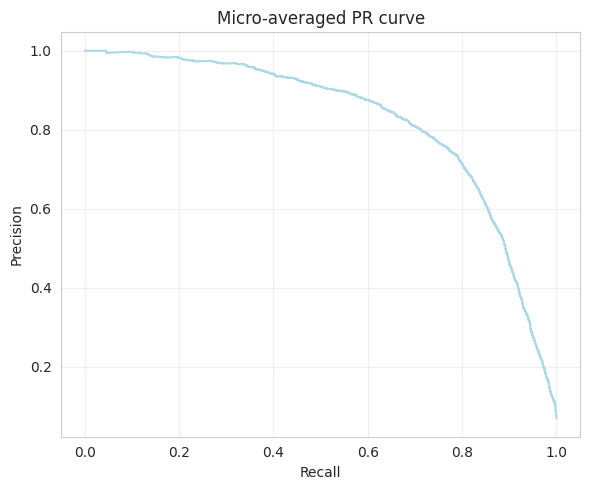

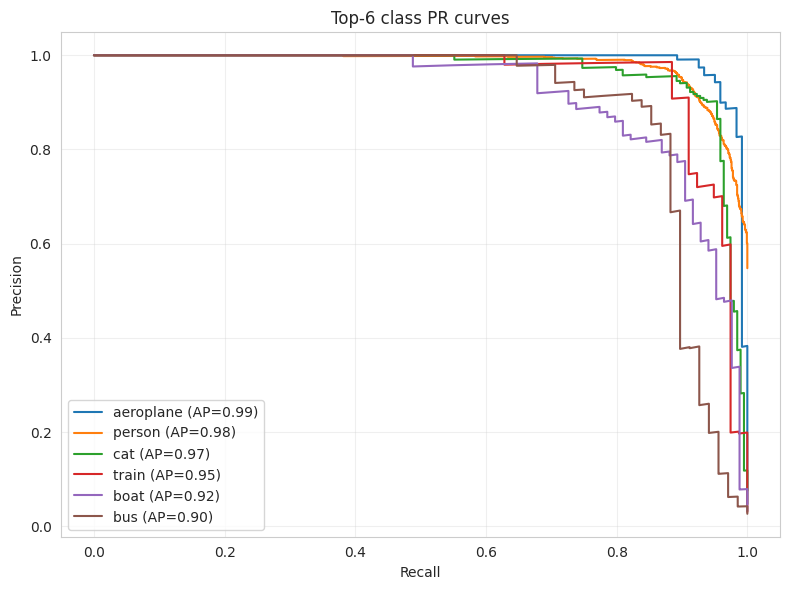

In [31]:
plot_pr_curves(y_test_true_eff, y_test_probs_eff, VOC_CLASSES, top_k=6, color="lightblue")

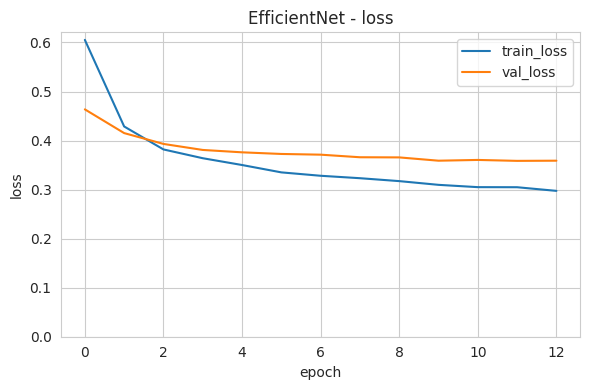

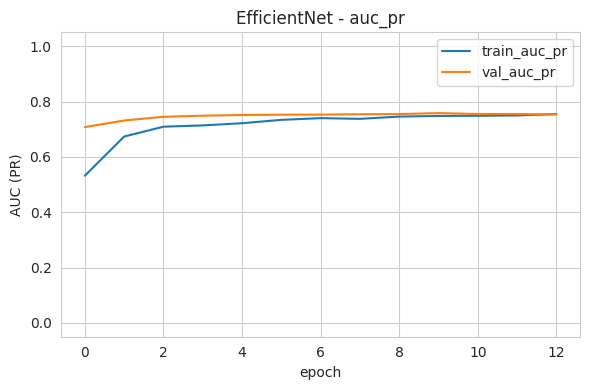

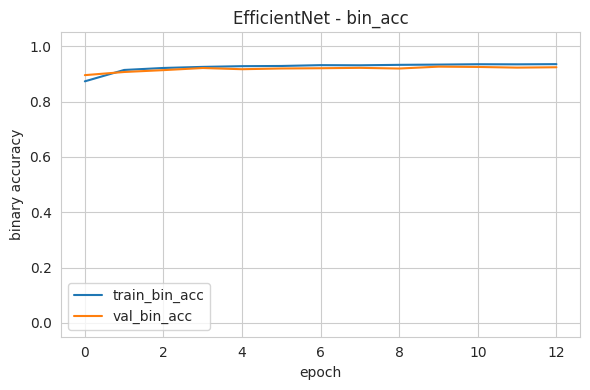

In [32]:
plot_training_curves(history, "EfficientNet")

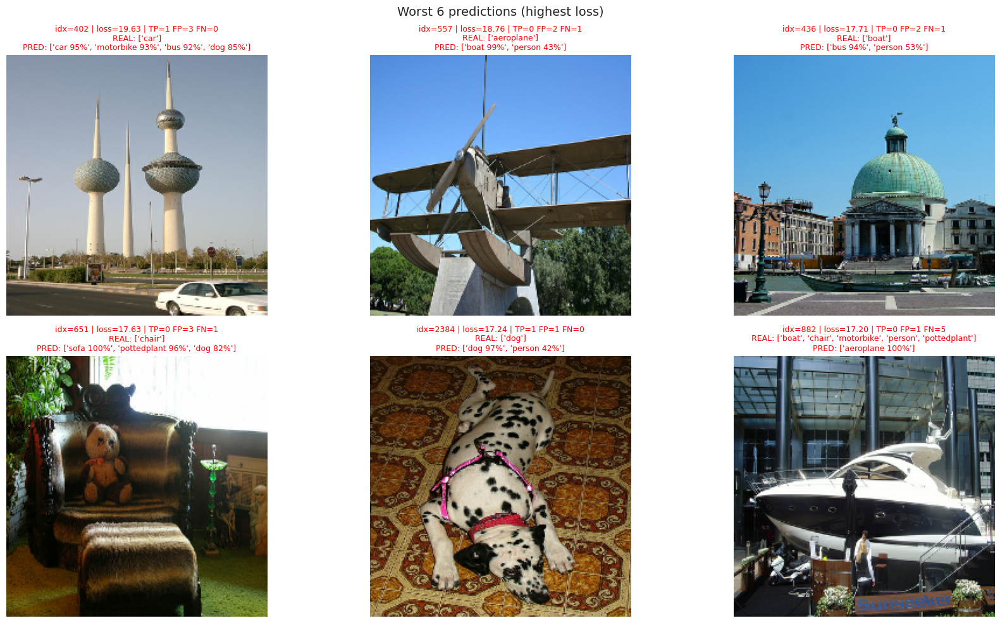

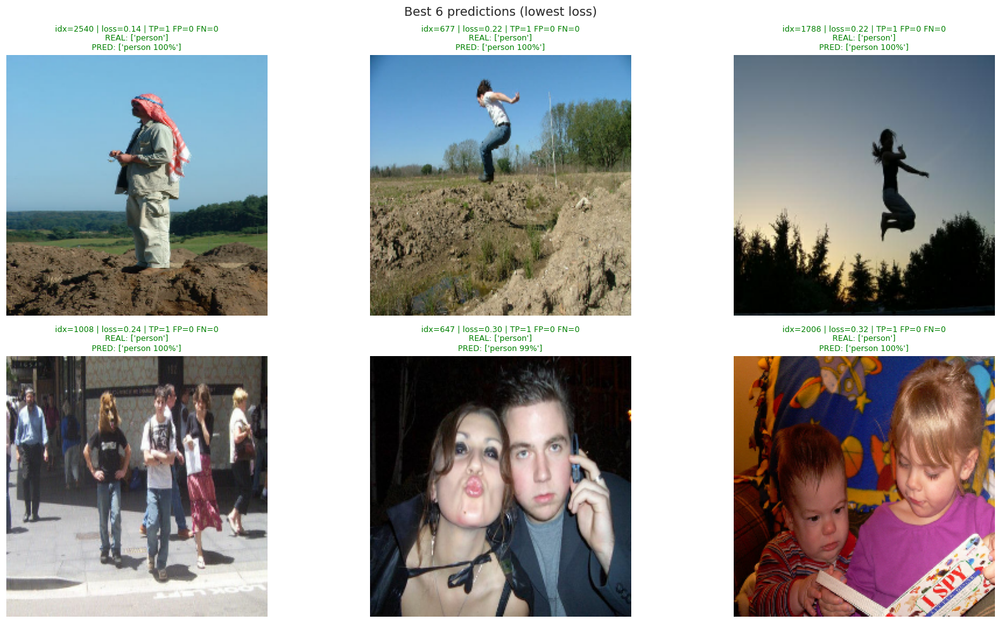

In [33]:
thresholds_vec = thresholds_eff

worst, bestk = show_best_worst_predictions(
    dataset=test_ds,
    y_true=y_test_true_eff,
    y_probs=y_test_probs_eff,
    thresholds_vec=thresholds_vec,
    class_names=VOC_CLASSES,
    k=6
)

### Fine Tuning

In [34]:

base_model.trainable = True

N = 30
for layer in base_model.layers[:-N]:
    layer.trainable = False


for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=weighted_bce_loss,
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc_pr", curve="PR", multi_label=True),
    ]
)


history_ft1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=1, min_lr=1e-7),
    ]
)


Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 73s 276ms/step - auc_pr: 0.7531 - bin_acc: 0.9372 - loss: 0.2978 - val_auc_pr: 0.7590 - val_bin_acc: 0.9296 - val_loss: 0.3469 - learning_rate: 1.0000e-05
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - auc_pr: 0.7542 - bin_acc: 0.9377 - loss: 0.2876 - val_auc_pr: 0.7608 - val_bin_acc: 0.9325 - val_loss: 0.3410 - learning_rate: 1.0000e-05
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - auc_pr: 0.7651 - bin_acc: 0.9375 - loss: 0.2850 - val_auc_pr: 0.7621 - val_bin_acc: 0.9329 - val_loss: 0.3392 - learning_rate: 5.0000e-06
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - auc_pr: 0.7671 - bin_acc: 0.9386 - loss: 0.2807 - val_auc_pr: 0.7622 - val_bin_acc: 0.9335 - val_loss: 0.3384 - learning_rate: 2.5000e-06
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 38s 202ms/step - auc_pr: 0.7711 - bin_acc: 0.9392 - loss: 0.2739 - val_auc_pr: 0.7630 - val_bin_acc: 0.9340 - val_loss: 0.3378 - learning_rate: 1.2500e-06
Epoch 6/15
188/188 ━━━━━━

### Valutazione modello fine tuning

Predizioni su VAL (EfficientNet FT)...
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step
Predizioni su TEST (EfficientNet FT)...
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step
VAL mAP: 0.7773
Top 5 classi (VAL):
    Class   AP_val  BestF1_val  BestThresh_val  Support_val
   person 0.976785    0.919958        0.359847         1444
    train 0.965127    0.924138        0.971490           75
      cat 0.960562    0.912387        0.980794          172
aeroplane 0.953751    0.933333        0.945996          118
    sheep 0.921716    0.893939        0.964115           71

Worst 5 classi (VAL):
      Class   AP_val  BestF1_val  BestThresh_val  Support_val
      horse 0.623536    0.656716        0.942666           80
       sofa 0.603113    0.600897        0.874012          116
      chair 0.587581    0.553763        0.884609          203
pottedplant 0.546292    0.577181        0.902485           87
     bottle 0.470293    0.500000        0.908380          141

==================== REPORT TEST (soglie da VA

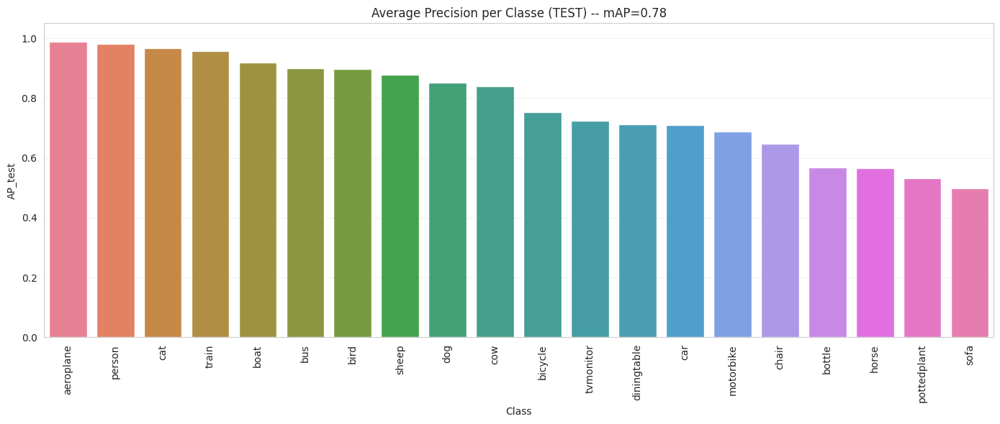

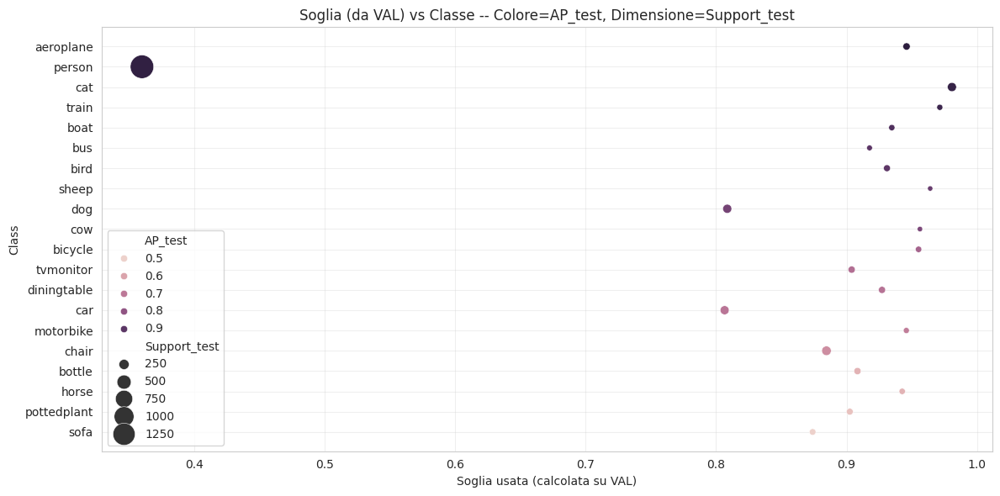

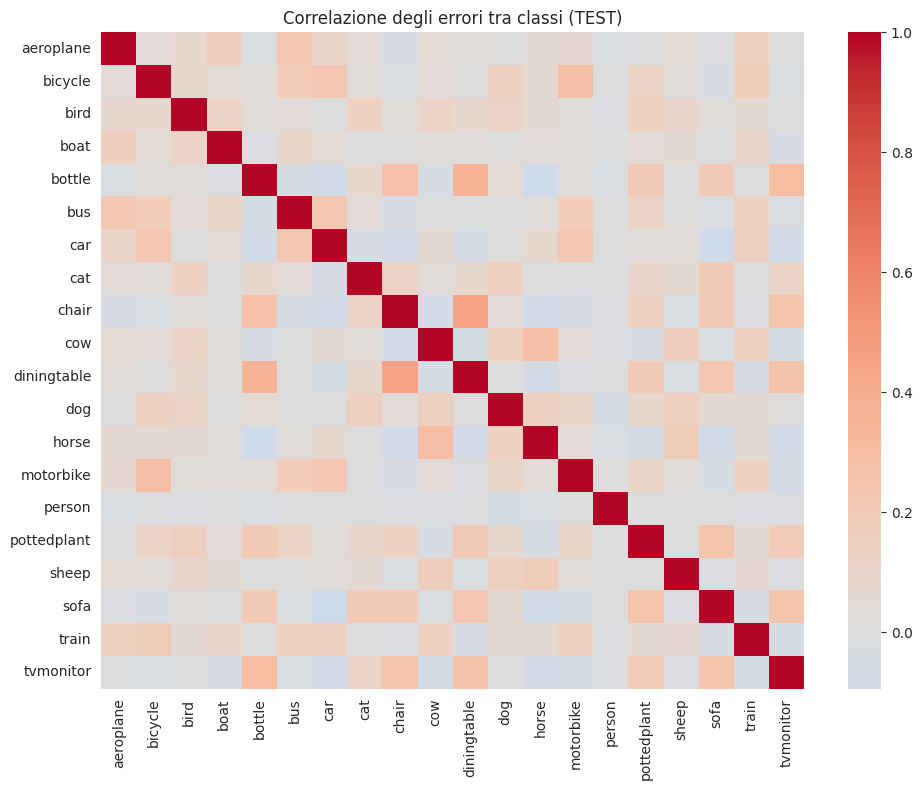

=== Optimal thresholds (da VAL) per classe ===
aeroplane    -> 0.945996
bicycle      -> 0.955225
bird         -> 0.930993
boat         -> 0.934704
bottle       -> 0.908380
bus          -> 0.917643
car          -> 0.806537
cat          -> 0.980794
chair        -> 0.884609
cow          -> 0.956272
diningtable  -> 0.927183
dog          -> 0.808547
horse        -> 0.942666
motorbike    -> 0.945837
person       -> 0.359847
pottedplant  -> 0.902485
sheep        -> 0.964115
sofa         -> 0.874012
train        -> 0.971490
tvmonitor    -> 0.903925
=== Optimal GLOBAL threshold (micro-F1 su VAL) ===
t_global = 0.8949999999999999 | micro-F1 = 0.7557644294316346
=== Ranking metrics (EfficientNet FT) ===
{'LRAP': 0.9069383551008061, 'RankingLoss': 0.02327461678398473, 'CoverageError': 2.039719626168224, 'P@3': 0.4114745586708204, 'R@3': 0.9294652128764279}


In [35]:
ft_eval = run_evaluation(model, "EfficientNet FT", val_ds, test_ds, VOC_CLASSES)

thresholds_ft = ft_eval["thresholds"]
df_val_metrics_ft = ft_eval["df_val_metrics"]
df_test_metrics_ft = ft_eval["df_test_metrics"]
mAP_val_ft = ft_eval["mAP_val"]
mAP_test_ft = ft_eval["mAP_test"]
summary_ft = ft_eval["summary"]
y_val_true_ft = ft_eval["y_val_true"]
y_val_probs_ft = ft_eval["y_val_probs"]
y_test_true_ft = ft_eval["y_test_true"]
y_test_probs_ft = ft_eval["y_test_probs"]

t_global_ft = ft_eval["t_global"]
f1_global_ft = ft_eval["f1_global"]

print_ranking_summary(y_test_true_ft, y_test_probs_ft, "EfficientNet FT", k=3)

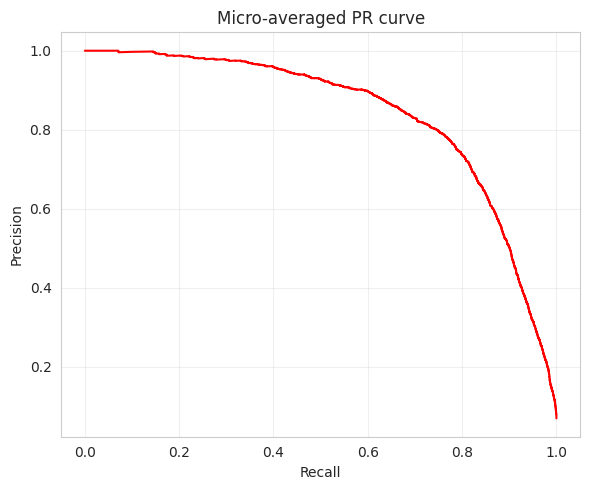

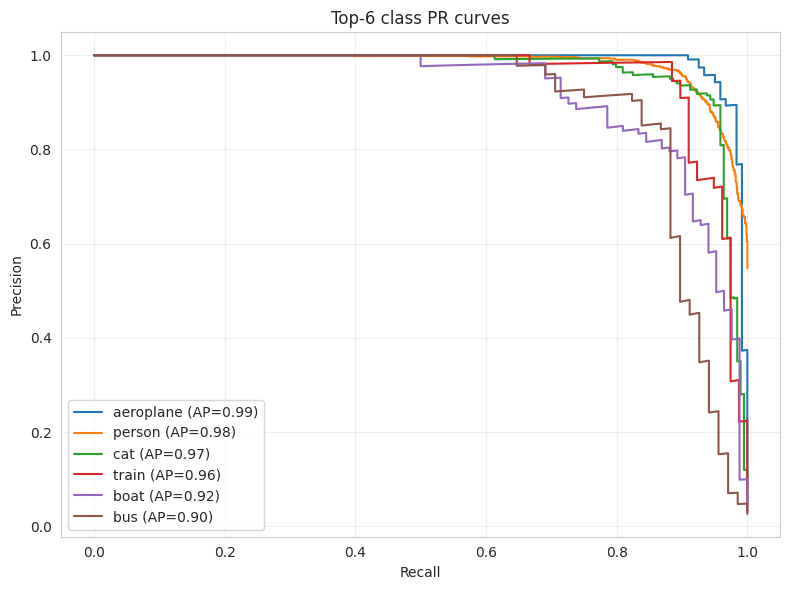

In [36]:
plot_pr_curves(y_test_true_ft, y_test_probs_ft, VOC_CLASSES, top_k=6, color="red")

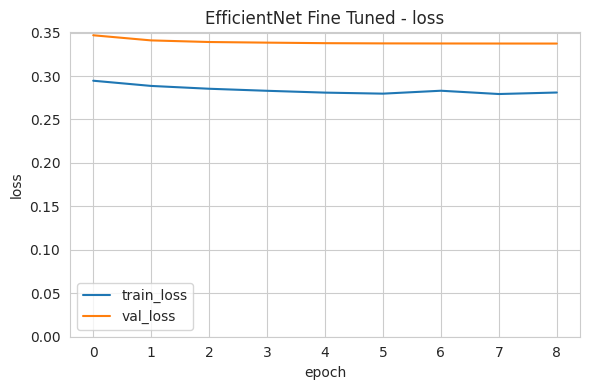

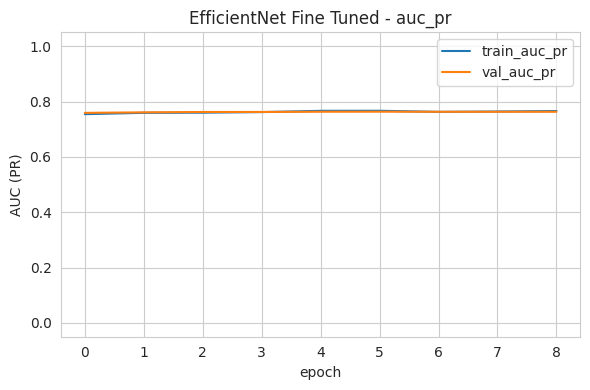

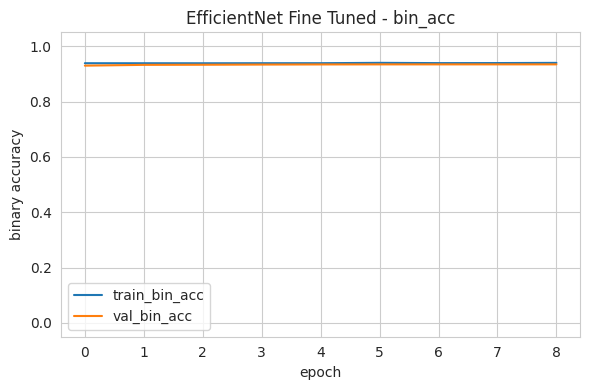

In [37]:
plot_training_curves(history_ft1, "EfficientNet Fine Tuned")

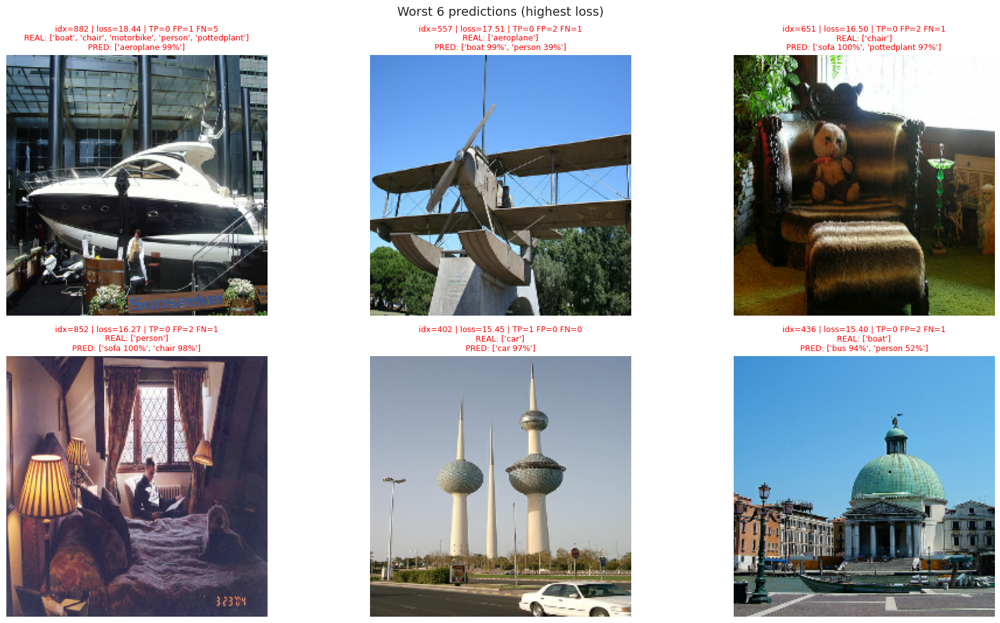

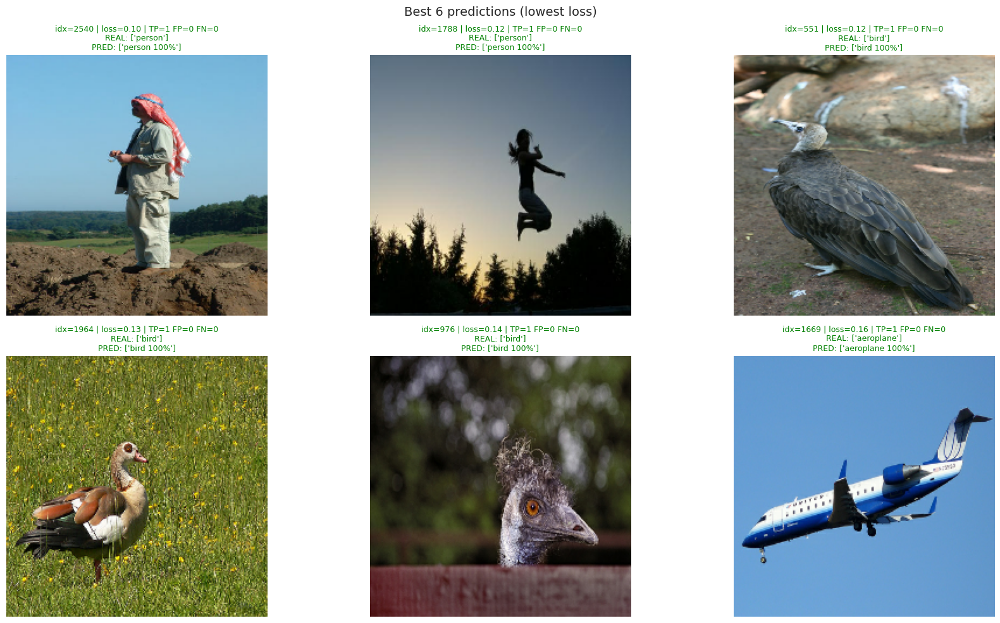

In [38]:
thresholds_vec = thresholds_ft

worst, bestk = show_best_worst_predictions(
    dataset=test_ds,
    y_true=y_test_true_ft,
    y_probs=y_test_probs_ft,
    thresholds_vec=thresholds_vec,
    class_names=VOC_CLASSES,
    k=6
)


## Confronto tra i modelli (CNN e EfficientNet) e risultati

Confronto tra le due reti realizzate

In [ ]:
# Use predictions saved at each evaluation stage. `model` has already been
# fine-tuned here, so calling model.predict() would not represent frozen TL.
y_true_cmp = y_test_true_cnn
assert np.array_equal(y_true_cmp, y_test_true_eff), "Test label order differs."
preds_cnn = y_test_probs_cnn
preds_eff = y_test_probs_eff
print("Comparing CNN with EfficientNet before fine-tuning.")


In [ ]:
comparison_data = []

for i, class_name in enumerate(VOC_CLASSES):
    ap_cnn = safe_average_precision(y_true_cmp[:, i], preds_cnn[:, i])
    ap_eff = safe_average_precision(y_true_cmp[:, i], preds_eff[:, i])

    improvement = ap_eff - ap_cnn

    comparison_data.append({
        "Class": class_name,
        "Baseline (CNN)": ap_cnn,
        "EfficientNet (TL)": ap_eff,
        "Improvement (+Delta)": improvement
    })

df_compare = pd.DataFrame(comparison_data).sort_values(by="EfficientNet (TL)", ascending=False)

map_cnn = df_compare["Baseline (CNN)"].mean()
map_eff = df_compare["EfficientNet (TL)"].mean()

print("\n" + "=" * 50)
print("RISULTATO DEL CONFRONTO (mAP sul Test Set)")
print("=" * 50)
print(f"Baseline (CNN from Scratch): {map_cnn:.4f}")
print(f"EfficientNet (Transfer Learn): {map_eff:.4f}")
print(f"GUADAGNO TOTALE: +{(map_eff - map_cnn):.4f} (Avg Precision)")
print("=" * 50)

In [ ]:
sns.set_style("whitegrid")

df_melted = df_compare.melt(id_vars=["Class"], value_vars=["Baseline (CNN)", "EfficientNet (TL)"],
                            var_name="Model", value_name="AP")

plt.figure(figsize=(14, 7))

sns.barplot(data=df_melted, x="Class", y="AP", hue="Model", palette=["#e74c3c", "#2ecc71"])

plt.title("Confronto Prestazioni per Classe: Baseline vs EfficientNet", fontsize=15)
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc="lower left")
plt.xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.barplot(data=df_compare, x="Class", y="Improvement (+Delta)", palette="Blues_r")

plt.title("Impatto del Transfer Learning: Guadagno di AP per Classe", fontsize=15)
plt.ylabel("Incremento di AP (EfficientNet - Baseline)")
plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("")

for i, v in enumerate(df_compare["Improvement (+Delta)"]):
    ax.text(i, v + 0.01, f"+{v:.2f}", ha='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
results = pd.DataFrame([
    results_row_extended(summary_cnn, mAP_test_cnn, y_test_true_cnn, y_test_probs_cnn, "CNN baseline", k=3),
    results_row_extended(summary_eff, mAP_test_eff, y_test_true_eff, y_test_probs_eff, "EfficientNet", k=3),
    results_row_extended(summary_ft, mAP_test_ft, y_test_true_ft, y_test_probs_ft, "EfficientNet FT", k=3),
]).sort_values("mAP", ascending=False)

results


,Model,mAP,AP_micro,AP_macro,F1_micro,F1_macro,F1_samples,LRAP,RankingLoss,CoverageError,P@3,R@3
2,EfficientNet FT,0.778833,0.839094,0.778833,0.802271,0.735017,0.823770,0.906938,0.023275,2.039720,0.411475,0.929465
1,EfficientNet,0.769625,0.823560,0.769625,0.796536,0.728747,0.818124,0.896769,0.026533,2.136682,0.409268,0.925961
0,CNN baseline,0.296837,0.302301,0.296837,0.472415,0.335973,0.468370,0.526190,0.154904,4.725467,0.245976,0.552057
